# <span style="color: #4B0082;">CMD + Isochrone/Track fitting</span>
Developed by Mariana de Aguiar Féo 
###### Version 1. (July 2026)


#### **<span style="color: #E6A100;">What this notebook can help with:**
- Makes Color Magnitude Diagrams
- Plot and fit isochrones
- Plot and fit track interpolation
- Estimate Progenitor Mass
- Check SN position and stars used in code against .fits files in DS9 automatically
- Create a region that can be manually inputted into DS9
- Analyze against GAIA catalog to ensure no crossover

### Setup and Imports

In [4]:
# core
import h5py                      # dolphot output is stored as an h5 file
import numpy as np               # for the radius cut, quality-cut masks, and general array math
import pandas as pd              # for building dataframes from the isochrone + track files
import matplotlib.pyplot as plt  # for the CMD, isochrone, and diagnostic plots
import matplotlib.cm as cm       # colormap used for the age-range isochrone overlay

# standard library
import glob                      # for finding track/isochrone files, even nested in subfolders
import zipfile                   # for extracting the MIST evolutionary track .zip bundle

# astropy / astroquery
import astropy.coordinates as coord      # SkyCoord + coordinate frames, used for the SN's RA/Dec
import astropy.units as u                # attaches units (deg, arcsec, mas) to coordinate/search values
from astropy.coordinates import SkyCoord # for matching HST local stars to Gaia sources on the sky
from astropy.wcs import WCS              # WCS class, does pixel <-> sky conversion
from astropy.io import fits              # for opening/reading the FITS reference image
from astroquery.ipac.irsa.irsa_dust import IrsaDust  # queries IRSA for foreground E(B-V) reddening

# If you have never used astroquery before you will need to add this dependency by running 
# pip install astroquery 
from astroquery.gaia import Gaia         # Gaia archive query client, for foreground-star cross-matching

In [5]:
# This is so you can cross reference with GAIA
# fix macOS SSL certificate verification for astroquery/Gaia (and any other HTTPS call)
# python.org's Python build doesn't automatically use the Mac system certificate
# store, so HTTPS requests can fail with "self-signed certificate in certificate
# chain" until certifi's bundle is explicitly pointed to

import certifi                                                          # certifi ships a trusted root CA bundle
import os                                                                # for setting environment variables

os.environ['SSL_CERT_FILE'] = certifi.where()                           # tell Python's ssl module to use certifi's bundle
os.environ['REQUESTS_CA_BUNDLE'] = certifi.where()                      # some libraries (requests-based) check this variable instead

# This only changes things in this environment/notebook, not on your actual computer

### CMD Plotting

In [6]:
# CMD TARGET SPECIFIC DATA INPUT!!
# this is the cell to change to run this on a different supernova/host galaxy. 
# Everything below this cell for plotting a CMD comes out of the .h5 file
# (SN position, photometry, quality flags) or is derived automatically from the numbers set here
# so none of it should need changing per-SN.

# Only other thing you *might* need to adjust later on are the values for quality cuts
# At the end of the notebook there is a cell called "Diagnostic 3" to help figure that out

# There are three other cells in this notebook where you will need to change input, all of them are marked with a comment "DATA INPUT!!"
# at the very top of the cell.

# path to the dp0000.h5 file that hst123/dolphot produced for this target
filepath = "/Users/mari/Research/summer26/supernovas/sn1964h/dp0000.h5"

# distance to the host galaxy should come from NED values for redshift independent distance 
# (http://ned.ipac.caltech.edu/byname?objname=ngc+1058&hconst=67.8&omegam=0.308&omegav=0.692&wmap=4&corr_z=1)
distance_mpc = 11.820       
distance_mpc_err = 1.266

# radius of the "local environment" I'm treating as associated with the
# SN's progenitor population, in physical units (parsecs) instead of a
# fixed angular size, so it means the same thing at any distance. 300 pc
# matches the aperture Singleton, Maund & Sun (2025, MNRAS, 540, 3204) used
# to isochrone-fit the resolved stellar population around another
# core-collapse SN (iPTF13bvn) with HST + DOLPHOT. Since it's basically the same
# method I'm using here, I'm using this as a base.
PHYSICAL_RADIUS_PC = 300.0  # Singleton, Maund & Sun 2025


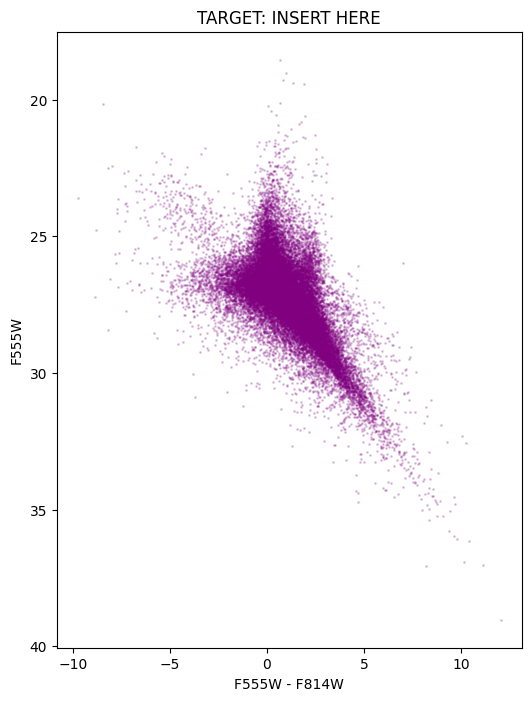

In [7]:
# plotting environment with dp0000.h5 file was is, no radial fix
# This radial cut should be happening in hst123 scrape dolphot flag, but it's not for some reason. We're working on it.
# So this radial fix might not be needed in the future.

# first pass CMD with every star in the field, no cuts besides removing dolphot's
# 99.99 "no measurement" flag value. this is before I added the radius cut,
# so it's the whole chip, not just the SN's local environment

#data grabbing columns for from photometry
with h5py.File(filepath, 'r') as f:
    f555 = f['photometry']['Instrumental_VEGAMAG_magnitude_ACS_F555W'][:]
    f814 = f['photometry']['Instrumental_VEGAMAG_magnitude_ACS_F814W'][:]

#filter out the 99.99 error inputs. I'm using 50 as a benchmark because anything dimmer would be incredible faint with HST
valid = (f555 < 50) & (f814 < 50)
f555 = f555[valid]
f814 = f814[valid]

#plotting
plt.figure(figsize=(6, 8))
plt.scatter(f555 - f814, f555, s=1, color="purple", alpha=0.2)   # color-mag scatter, small points since this is the whole field and there is a lot

plt.gca().invert_yaxis() #Brighter stars at the top
plt.xlabel("F555W - F814W")
plt.ylabel("F555W")
plt.title("TARGET: INSERT HERE")

plt.show()


In [8]:
# pulling the SN's RA/Dec and its pixel position (x,y) on the reference image
# straight from the file instead of typing them in by hand, so it stays tied
# to whatever hst123/dolphot actually solved for
with h5py.File(filepath, 'r') as f:
    scraped = f['scraped_photometry'].attrs
    sn_ra = scraped['ra']
    sn_dec = scraped['dec']
    sn_x = float(scraped['x'])
    sn_y = float(scraped['y'])

print(f"SN RA/Dec: {sn_ra}, {sn_dec}")
print(f"SN pixel position: x={sn_x}, y={sn_y}")


SN RA/Dec: 337.09982112931533, 30.289858588465854
SN pixel position: x=2611.8, y=2597.78


In [9]:
# DERIVED: distance modulus + physical radius cut, in pixels
# Everything here is computed from distance_mpc / PHYSICAL_RADIUS_PC (the
# target-inputs cell above) plus the ACS/WFC plate scale, so for this part
# only ever have to edit the numbers up there for a new target!!!

distance_pc = distance_mpc * 1e6                     # Mpc -> pc

# standard distance modulus definition: mu = 5*log10(d[pc]) - 5
distance_modulus = 5 * np.log10(distance_pc) - 5
print(f"distance_modulus = {distance_modulus:.3f} mag "
    )

# ACS/WFC plate scale
# 0.05 arcsec/pixel is the standard, documented
# value for the Wide Field Channel (STScI ACS Instrument Handbook,
# hst-docs.stsci.edu), not something specific to this field, so I'm
# citing it directly 
PLATE_SCALE = 0.05  # arcsec/pixel

# converting the physical aperture (target-inputs cell) into an angular
# size at this specific distance, using the small-angle formula
# theta[arcsec] = (physical_size[pc] / distance[pc]) * 206265
# (206265 = arcsec per radian, conversion constant)
max_radius_arcsec = (PHYSICAL_RADIUS_PC / distance_pc) * 206265
max_radius_pixels = max_radius_arcsec / PLATE_SCALE

print(f"PHYSICAL_RADIUS_PC = {PHYSICAL_RADIUS_PC} pc -> {max_radius_arcsec:.3f} arcsec "
      f"-> {max_radius_pixels:.2f} pixels at {distance_mpc} Mpc")


distance_modulus = 30.363 mag 
PHYSICAL_RADIUS_PC = 300.0 pc -> 5.235 arcsec -> 104.70 pixels at 11.82 Mpc


In [17]:
# FOREGROUND REDDENING E(B-V), automatically from the SN's RA/Dec.
# This is pulled automaticallty. 

# assuming sn_ra/sn_dec (from the scraped_photometry attrs, cell 5) are in
# decimal degrees, which is the standard hst123 output
# if this throws a coordinate-parsing error check inside the file 
# using the second cell under "Looking inside files" Section
sn_coord = coord.SkyCoord(ra=sn_ra * u.deg, dec=sn_dec * u.deg, frame='icrs')

# IRSA's dust service returns both the original Schlegel, Finkbeiner &
# Davis (1998) values and the Schlafly & Finkbeiner (2011) recalibration;
# 'ext SandF mean' is the S&F (2011) reddening, the more current
# calibration, so that's the one I'm using
dust_table = IrsaDust.get_query_table(sn_coord, section='ebv')
E_BV = float(dust_table['ext SandF mean'][0])

A_V = 3.1 * E_BV   # R_V = 3.1, standard Milky Way extinction law (Cardelli et al. 1989)

# extinction coefficients for a hot star (appropriate since the local
# population is young/massive-star dominated), interpolated from
# Holtzman et al. 1995 Table 12A (O6 spectrum), consistent with the
# Cardelli et al. 1989 R_V=3.1 extinction law
A_F555W = 1.00 * A_V   # Holtzman et al. 1995, O6 spectrum
A_F814W = 0.57 * A_V   # Holtzman et al. 1995, O6 spectrum

print(f"E(B-V) = {E_BV:.4f} mag")
print(f"A_V    = {A_V:.4f} mag")

# Note -> I'm no longer setting extinction on MIST
# I'm letting the code do the correction using the A_F555 and A_F814 functions


E(B-V) = 0.0529 mag
A_V    = 0.1640 mag


Using SN center: x=2611.80, y=2597.78


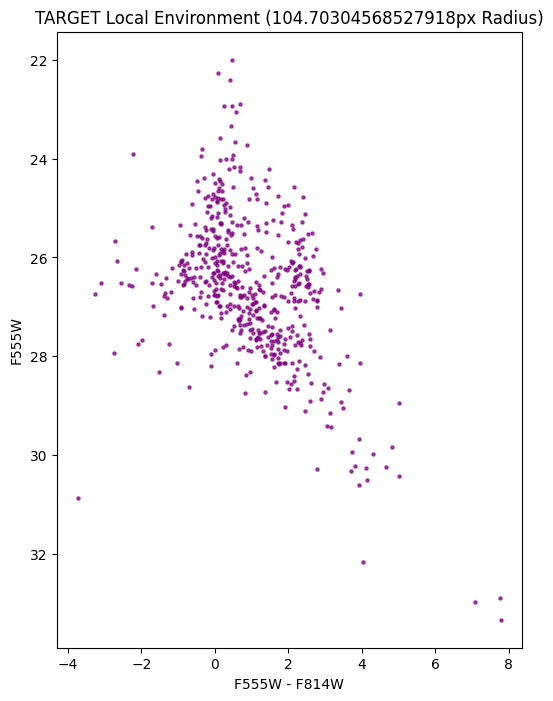

In [18]:
# Imposing radial filter to clean up!!!!
# Because we don't know why hst123's radius-cut option isn't working right now
# I'm imposing the 5" radius by hand here instead, directly on the dolphot output, as a workaround

# Data grabbing columns from photometry
with h5py.File(filepath, 'r') as f:
    photo = f['photometry']
    f555 = photo['Instrumental_VEGAMAG_magnitude_ACS_F555W'][:]
    f814 = photo['Instrumental_VEGAMAG_magnitude_ACS_F814W'][:]
    
    # Extract the exact pixel coordinate columns from DOLPHOT
    x_coords = photo['Object_X_position_on_reference_image_or_first_image_if_no_refer'][:]
    y_coords = photo['Object_Y_position_on_reference_image_or_first_image_if_no_refer'][:]

#numpy radial dfilter
#pixel location of SN on the reference image!!! I opened the dp0000.h5 file to find this information
with h5py.File(filepath, 'r') as f:
    scraped = f['scraped_photometry'].attrs
    center_x = float(scraped['x'])
    center_y = float(scraped['y'])

print(f"Using SN center: x={center_x:.2f}, y={center_y:.2f}")

# PLATE_SCALE / max_radius_arcsec / max_radius_pixels are computed once, from
# distance_mpc + PHYSICAL_RADIUS_PC, in the "DERIVED: distance modulus +
# physical radius" cell 

# Calculate pixel distances 
distances_pixels = np.sqrt((x_coords - center_x)**2 + (y_coords - center_y)**2)

# Filter out the 99.99 error inputs AND isolate the tight circle environment
valid = (f555 < 50) & (f814 < 50) & (distances_pixels < max_radius_pixels)
f555 = f555[valid]
f814 = f814[valid]

# Plotting!!!
plt.figure(figsize=(6, 8))
plt.scatter(f555 - f814, f555, s=5, color="purple", alpha=0.7)

plt.gca().invert_yaxis() # Brighter stars at the top
plt.xlabel("F555W - F814W")
plt.ylabel("F555W")
plt.title(f"TARGET Local Environment ({max_radius_pixels}px Radius)")

plt.show()


Using SN center: x=2611.80, y=2597.78
Stars after cuts + exclusion: 109


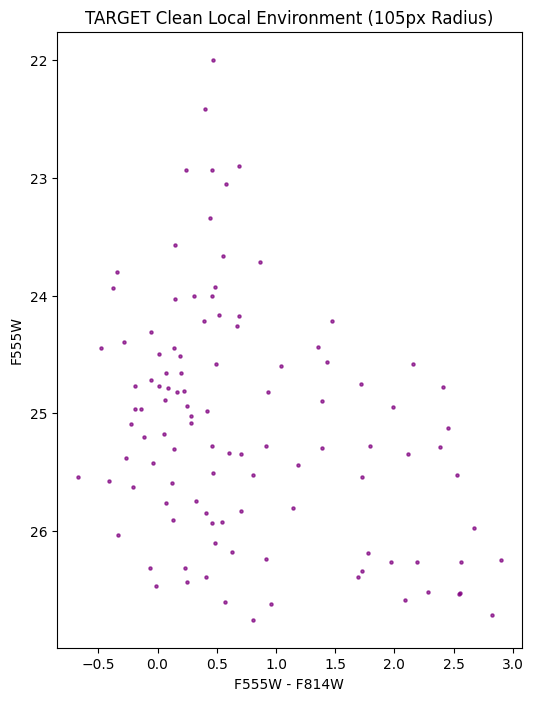

In [19]:
# radial filter + quality cuts!!
# same idea as the cell above but now adding DOLPHOT's quality flags
# (SNR, sharpness, crowding) on top of the radius cut
# so the CMD isn't full of cosmic rays, blends, and other funky detections

# Data columns from photometry
with h5py.File(filepath, 'r') as f:
    photo = f['photometry']
    f555 = photo['Instrumental_VEGAMAG_magnitude_ACS_F555W'][:]
    f814 = photo['Instrumental_VEGAMAG_magnitude_ACS_F814W'][:]

    # Extract the exact pixel coordinate columns from DOLPHOT
    x_coords = photo['Object_X_position_on_reference_image_or_first_image_if_no_refer'][:]
    y_coords = photo['Object_Y_position_on_reference_image_or_first_image_if_no_refer'][:]

    # Loaded object type and quality flags to automate the new cuts
    obj_type = photo['Object_type_1_bright_star_2_faint_3_elongated_4_hot_pixel_5_ext'][:]
    flag_555 = photo['Photometry_quality_flag_ACS_F555W'][:]
    flag_814 = photo['Photometry_quality_flag_ACS_F814W'][:]

    # quality columns for F555
    snr_555 = photo['Signal_to_noise_ACS_F555W'][:]
    sharp_555 = photo['Sharpness_ACS_F555W'][:]
    crowd_555 = photo['Crowding_ACS_F555W'][:]
    
    # quality columns for F814
    snr_814 = photo['Signal_to_noise_ACS_F814W'][:]
    sharp_814 = photo['Sharpness_ACS_F814W'][:]
    crowd_814 = photo['Crowding_ACS_F814W'][:]

    # SN center pulled from the scrape file 
    scraped = f['scraped_photometry'].attrs
    center_x = float(scraped['x'])
    center_y = float(scraped['y'])

print(f"Using SN center: x={center_x:.2f}, y={center_y:.2f}")

# numpy radial filter
# PLATE_SCALE / max_radius_arcsec / max_radius_pixels are computed once, from
# distance_mpc + PHYSICAL_RADIUS_PC, in the "DERIVED: distance modulus +
# physical radius" cell above 

# Calculate pixel distances
distances_pixels = np.sqrt((x_coords - center_x)**2 + (y_coords - center_y)**2)

#Quality filters!!!!!
# thresholds below are the general-purpose DOLPHOT cuts I've seen used in
# resolved stellar population papers (SNR >= 3-5, sharpness^2 < ~0.1,
# crowding < ~0.5-1). I picked round numbers in that range rather than
# pulling them from one specific paper. REMEMBER to confirm these are
# reasonable for a local-environment/progenitor study before I cite them
valid = (
    (f555 < 50) & (f814 < 50) &
    (distances_pixels < max_radius_pixels) &
    (obj_type == 1) &                               # Only good stars
    (flag_555 <= 0) & (flag_814 <= 0) &             # Standard quality flags
    (snr_555 >= 5.0) & (snr_814 >= 5.0) &           # Rule out noisy junk, both bands
    (crowd_555 < 0.5) & (crowd_814 < 0.5) &         # Rule out overlapping stars, both bands
    (sharp_555 > -0.2) & (sharp_555 < 0.2) &        # Sharpness cuts instead of squared bounds
    (sharp_814 > -0.4) & (sharp_814 < 0.4)
)

f555 = f555[valid]
f814 = f814[valid]

print(f"Stars after cuts + exclusion: {valid.sum()}") # This helps later if I need to see how many stars were cut by this step

# Plotting!!!
plt.figure(figsize=(6, 8))
plt.scatter(f555 - f814, f555, s=5, color="purple", alpha=0.7)

plt.gca().invert_yaxis() # Brighter stars at the top
plt.xlabel("F555W - F814W")
plt.ylabel("F555W")
plt.title(f"TARGET Clean Local Environment ({max_radius_pixels:.0f}px Radius)")
plt.show()

In [20]:
# STAR POSITIONS: pixel coordinates + RA/Dec for stars in the local environment
# Added on 07/26 
# uses the 'valid' mask (radius + quality cuts, from the cell above), and the WCS
# from the drizzled F814W image dolphot aligned everything to (img0000 in the .h5
# metadata, so the "reference image" that Object_X/Y_position are measured on)

# DATA INPUT!!!
reference_fits = "/Users/mari/Research/summer26/supernovas/sn1964h/acs.f814w.ut221110_0002.drc.fits"  # path to the reference image dolphot aligned to

with fits.open(reference_fits) as hdul:                              # open the FITS file (auto-closes after the block)
    header = None                                                    # will hold whichever header actually has the WCS
    for hdu in hdul:                                                 # loop through every extension (primary + SCI etc.)
        if 'CRVAL1' in hdu.header:                                   # this extension has real WCS keywords
            header = hdu.header                                      # grab that header
            break                                                    # stop looking, found it
    if header is None:                                               # none of the extensions had WCS keywords
        raise ValueError(f"No WCS keywords (CRVAL1) found in any extension of {reference_fits}")  # bail out loudly instead of silently guessing
    wcs = WCS(header)                                                # build the WCS object from that header

star_x = x_coords[valid]                                             # pixel x for stars that passed the cuts
star_y = y_coords[valid]                                             # pixel y for stars that passed the cuts

star_ra, star_dec = wcs.wcs_pix2world(star_x, star_y, 1)             # convert pixel -> RA/Dec, origin=1 matches DOLPHOT/FITS convention

check_ra, check_dec = wcs.wcs_pix2world(sn_x, sn_y, 1)                # sanity check: run the SN's own pixel position through the same WCS
print(f"WCS sanity check, SN RA/Dec recovered from pixel position: {check_ra:.6f}, {check_dec:.6f}")  # print what the WCS thinks the SN's RA/Dec is
print(f"                     SN RA/Dec scraped from the .h5 file:    {sn_ra:.6f}, {sn_dec:.6f}")         # print the SN's actual scraped RA/Dec, for comparison
print()                                                               # blank line for readability

print(f"{'#':<4} {'x (px)':<10} {'y (px)':<10} {'RA (deg)':<14} {'Dec (deg)'}")  # table header
for i, (x, y, ra, dec) in enumerate(zip(star_x, star_y, star_ra, star_dec)):     # loop over every star, paired with its index
    print(f"{i:<4} {x:<10.2f} {y:<10.2f} {ra:<14.6f} {dec:.6f}")                 # print one row per star

print(f"\n{len(star_x)} stars total (radius + quality cuts applied)")            # final count, for a sanity check against earlier cells

WCS sanity check, SN RA/Dec recovered from pixel position: 337.099813, 30.289866
                     SN RA/Dec scraped from the .h5 file:    337.099821, 30.289859

#    x (px)     y (px)     RA (deg)       Dec (deg)
0    2648.81    2596.63    337.099218     30.289850
1    2606.17    2638.01    337.099904     30.290424
2    2655.45    2583.06    337.099111     30.289661
3    2600.34    2585.54    337.099997     30.289696
4    2674.13    2594.45    337.098811     30.289819
5    2695.77    2603.15    337.098462     30.289940
6    2621.56    2597.83    337.099656     30.289866
7    2668.06    2620.44    337.098908     30.290180
8    2704.04    2619.20    337.098329     30.290163
9    2642.17    2568.47    337.099325     30.289458
10   2710.12    2597.07    337.098232     30.289856
11   2620.33    2627.20    337.099676     30.290274
12   2699.56    2602.33    337.098401     30.289929
13   2695.30    2590.24    337.098470     30.289761
14   2640.60    2593.24    337.099350     30.289802
15 

#### **<span style="color: #E6A100;">Looking inside files:**


In [418]:
# inspect name of stuff h5 inside file
# I used this while developing this code to just checking whether 'photometry' 
# is a group (multiple datasets) or a single structured dataset, so I'd know 
# how to pull individual columns out of it.
# I'm keeping it here though because it could be useful to check while developing
# other things for this notebook

with h5py.File(filepath, 'r') as f:
    data = f['photometry']
    
    if isinstance(data, h5py.Group):
        print("Keys inside 'photometry':", list(data.keys()))
    else:
        print("Columns inside 'photometry':", data.dtype.names)
        


Columns inside 'photometry': ('Extension_zero_for_base_image', 'Chip_for_three_dimensional_FITS_image', 'Object_X_position_on_reference_image_or_first_image_if_no_refer', 'Object_Y_position_on_reference_image_or_first_image_if_no_refer', 'Chi_for_fit', 'Signal_to_noise', 'Object_sharpness', 'Object_roundness', 'Direction_of_major_axis_if_not_round', 'Crowding', 'Object_type_1_bright_star_2_faint_3_elongated_4_hot_pixel_5_ext', 'Total_counts_WFPC2_F300W', 'Total_sky_level_WFPC2_F300W', 'Normalized_count_rate_WFPC2_F300W', 'Normalized_count_rate_uncertainty_WFPC2_F300W', 'Instrumental_VEGAMAG_magnitude_WFPC2_F300W', 'Transformed_UBVRI_magnitude_WFPC2_F300W', 'Magnitude_uncertainty_WFPC2_F300W', 'Chi_WFPC2_F300W', 'Signal_to_noise_WFPC2_F300W', 'Sharpness_WFPC2_F300W', 'Roundness_WFPC2_F300W', 'Crowding_WFPC2_F300W', 'Photometry_quality_flag_WFPC2_F300W', 'Total_counts_ACS_F555W', 'Total_sky_level_ACS_F555W', 'Normalized_count_rate_ACS_F555W', 'Normalized_count_rate_uncertainty_ACS_F555W'

In [419]:
# finding more info, particularly i want the pixel position for the supernova!!
# Dumping every top-level key/attribute so I can see where dolphot/hst123 stored
# the SN's actual coordinates, under 'scraped_photometry'
# This was another cell used during development, but that i'm leaving here
# in case anything else is needed.

with h5py.File(filepath, 'r') as f:
    print("Top-level keys:", list(f.keys()))
    print()
    print("Top-level attributes:", dict(f.attrs))
    print()
    for key in f.keys():
        print(f"--- Group: {key} ---")
        print("  Attributes:", dict(f[key].attrs))
        if hasattr(f[key], 'keys'):
            print("  Sub-keys:", list(f[key].keys()))
        print()


Top-level keys: ['metadata', 'photometry', 'scraped_photometry']

Top-level attributes: {}

--- Group: metadata ---
  Attributes: {'global_param_json': '{\n  "Nimg": "6",\n  "FitSky": "2",\n  "SkipSky": "2",\n  "RCombine": "1.5",\n  "SkySig": "2.25",\n  "SecondPass": "1",\n  "SigFindMult": "0.85",\n  "MaxIT": "25",\n  "NoiseMult": "0.1",\n  "FSat": "0.999",\n  "ApCor": "1",\n  "RCentroid": "2",\n  "PosStep": "0.25",\n  "dPosMax": "2.5",\n  "SigPSF": "5.0",\n  "PSFres": "1",\n  "Align": "0",\n  "Rotate": "1",\n  "ACSuseCTE": "0",\n  "WFC3useCTE": "0",\n  "WFPC2useCTE": "1",\n  "FlagMask": "7",\n  "SigFind": "2.5",\n  "SigFinal": "3.5",\n  "UseWCS": "2",\n  "AlignOnly": "0",\n  "AlignIter": "5",\n  "AlignTol": "0.5",\n  "AlignStep": "4.0",\n  "VerboseData": "1",\n  "NegSky": "1",\n  "Force1": "1",\n  "DiagPlotType": "PNG",\n  "InterpPSFlib": "1",\n  "FakeMatch": "3.0",\n  "FakePSF": "2.0",\n  "FakeStarPSF": "1",\n  "FakePad": "0"\n}', 'merged_images_json': '{\n  "img0000": {\n    "param"

### Isochrone fitting

In [21]:
# DATA INPUT CELL!!

# path to the MIST isochrone grid matching this host's metallicity
# Use the output value from the cell above for the Extinction value
# ([Fe/H] gets checked against the file's own header a few cells down)
# but to generate MIST I usually go to NED catalog to find the host galaxy metalicity or check literature

isochrone_path = "/Users/mari/Research/MIST_iso_6a5ebe91f2f86.iso.HST_ACS_WFC" #change this to set the path to isochrone file

# MIST version number  = 1.2     
# MESA revision number =     7503
# photometric system   = HST/ACS/WFC (Vega)                                              
# --------------------------------------------------------------------------------------
#  Yinit        Zinit   [Fe/H]   [a/Fe]  v/vcrit                                        
# 0.2566  5.87403E-03    -0.50     0.00     0.40
# --------------------------------------------------------------------------------------
# number of isochrones =   401
# extinction:   Av, Rv =  0.029 3.100
# --------------------------------------------------------------------------------------
# number of EEPs, cols =   279   24
#   1                               2                               3                               4                               5                               6                               7                               8                               9                  10                  11                  12           

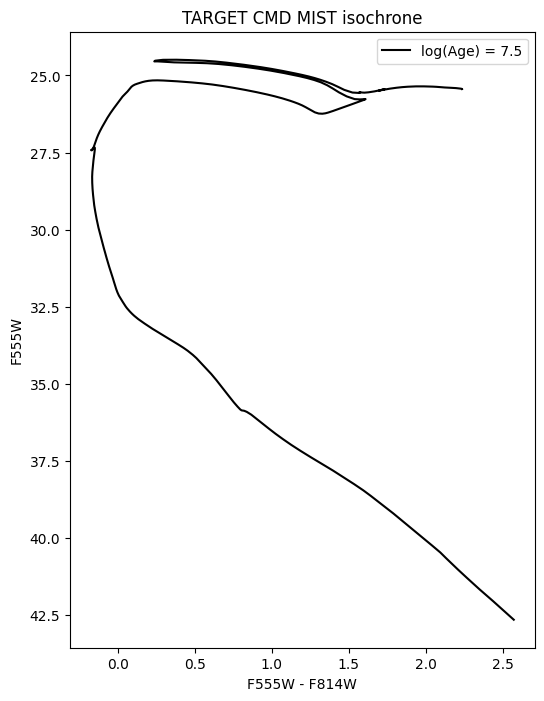

In [22]:
# DEVELOPING NOTE: MERGE THIS WITH NEXT CELL
# isochrone!! 
# now loading a MIST isochrone grid and overlaying it on the CMD to estimate
# the age of the stellar population around the SN

# isochrone_path is now set in the target-inputs cell up top!!
with open(isochrone_path) as f:
    header_check = [l for l in f.readlines()[:15] if l.startswith('#')]
print(''.join(header_check))
# Check that [Fe/H] matches host metallicity 
# against the printed header instead of asserting it in code
# (If value is not available, we would use 0 and assume solar-like)

#read file. set mist to HST ACS/WFC bc that's the camera we're using
def read_mist_iso(filepath):                                    # parser function
    with open(filepath) as f:                                   # open iso file
        lines = f.readlines()                                    # read all lines

    colnames = None                                               # column names holder
    data_rows = []                                                # numeric data rows

    for line in lines:                                            # loop through lines
        if line.startswith('#'):                                 # comment/header line
            if 'EEP' in line and 'log10_isochrone_age_yr' in line and colnames is None:  # real header line
                colnames = line.lstrip('#').split()               # grab column names
            continue                                               # skip comment lines
        if line.strip():                                          # skip blank lines
            data_rows.append(line.split())                        # collect data row

    data = np.array(data_rows, dtype=float)                       # convert to array
    return colnames, data                                         # return names + data

colnames, data = read_mist_iso(isochrone_path)                    # parse the file

print(len(colnames), data.shape)                                  # sanity check shapes match

iso_df = pd.DataFrame(data, columns=colnames)                     # build dataframe

print(iso_df.columns.tolist())                                    # check column names

# target age!!!!
# This is just so you can fit the expected age, if there is any from literature.
# You'll get another cell to replot this once you have the best age fit from your data
target_log_age = 7.5                                               # target age (log yr)

iso_mask = np.isclose(iso_df['log10_isochrone_age_yr'], target_log_age)  # age mask

iso_f555 = iso_df['ACS_WFC_F555W'][iso_mask].values                 # isochrone F555W
iso_f814 = iso_df['ACS_WFC_F814W'][iso_mask].values                 # isochrone F814W

# "FOREGROUND REDDENING" cell up in the CMD Section (auto-queried from IRSA instead of
# hardcoded)

shifted_f555 = iso_f555 + distance_modulus + A_F555W             # shift F555W
shifted_f814 = iso_f814 + distance_modulus + A_F814W             # shift F814W

# plot over existing plot (makes it not look squished :) )
plt.figure(figsize=(6, 8))                                          # set figure size

# plt.scatter(f555 - f814, f555, s=1, color="purple", alpha=0.3)    # real data points

plt.plot(shifted_f555 - shifted_f814, shifted_f555,                 # plot isochrone
          color="black", label=f"log(Age) = {target_log_age}")

plt.gca().invert_yaxis()                                            # brighter stars up top
plt.xlabel("F555W - F814W")                                         # x-axis label
plt.ylabel("F555W")                                                 # y-axis label
plt.title("TARGET CMD MIST isochrone")                     # plot title
plt.legend()                                                         # show legend
plt.show()                                                           # display plot

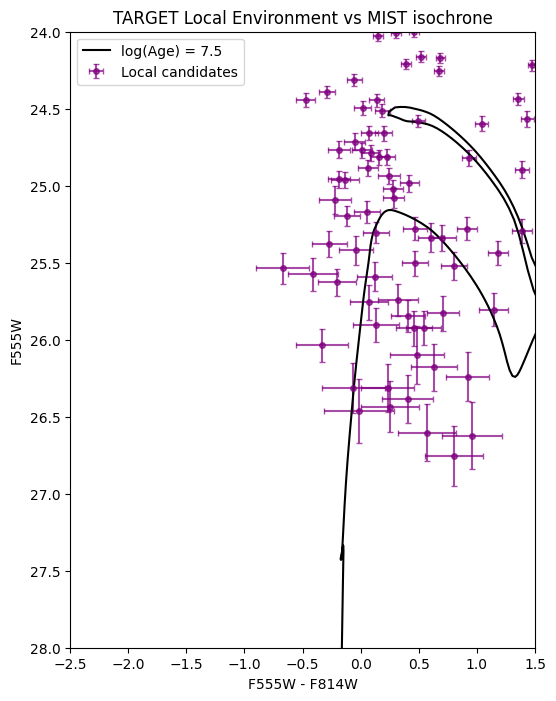

In [23]:
# Isochrone + stars in local environment!!!
# Instead of just the isochrone by itself i'm gonna reuse 'valid' from the quality-cut cell

with h5py.File(filepath, 'r') as f:
    photo = f['photometry']
    err_555 = photo['Magnitude_uncertainty_ACS_F555W'][:][valid]
    err_814 = photo['Magnitude_uncertainty_ACS_F814W'][:][valid]
color_err = np.sqrt(err_555**2 + err_814**2)   # propagate F555W/F814W errors into a color error

plt.figure(figsize=(6, 8))
plt.errorbar(f555 - f814, f555, xerr=color_err, yerr=err_555, fmt='o', color="purple", markersize=4, alpha=0.7, capsize=2, label="Local candidates")
plt.plot(shifted_f555 - shifted_f814, shifted_f555, color="black", label="log(Age) = 7.5")
plt.gca().invert_yaxis()
plt.xlabel("F555W - F814W")
plt.ylabel("F555W")
plt.title("TARGET Local Environment vs MIST isochrone")
plt.legend()
plt.ylim(28, 24)   # zooming into the magnitude range where the local candidates actually sit
plt.xlim(-2.5, 1.5)
plt.show()


In [24]:
# FUNCTION: fit_best_age
# Pulled out of the "age range isochrone!!" cell so it can be reused for the
# distance Monte Carlo (each trial distance needs its own age fit, so this
# needs to be callable instead of just sitting inline in one cell)
# Takes a distance modulus and returns the best-fit log(age), using the same
# error-weighted chi2 -> likelihood -> PDF approach as before

def fit_best_age(distance_modulus_val, ages_fine=None):               # distance_modulus_val lets the Monte Carlo pass in different trial distances
    if ages_fine is None:                                              # default age grid, same as the original cell
        ages_fine = np.arange(6.0, 10.01, 0.05)                        # log(yr) grid to test

    data_color = f555 - f814                                           # local candidate colors (same stars as everywhere else)

    chi2_per_age = []                                                  # (age, chi2) pairs, error-weighted

    for age in ages_fine:                                              # loop over every trial age
        mask = np.isclose(iso_df['log10_isochrone_age_yr'], age, atol=0.01)  # this age's isochrone track
        if mask.sum() == 0:                                            # skip ages missing from the grid
            continue
        iso_555 = iso_df['ACS_WFC_F555W'][mask].values + distance_modulus_val + A_F555W  # shift isochrone F555W using the passed-in distance modulus
        iso_814 = iso_df['ACS_WFC_F814W'][mask].values + distance_modulus_val + A_F814W  # shift isochrone F814W using the passed-in distance modulus
        iso_color = iso_555 - iso_814                                  # isochrone color at this age

        chi2 = 0.0                                                     # running chi2 total for this age
        for c, m, ce, me in zip(data_color, f555, color_err, err_555): # loop over every star + its own errors
            d2 = ((c - iso_color) / ce)**2 + ((m - iso_555) / me)**2   # error-weighted squared distance, in units of each star's own sigma
            chi2 += d2.min()                                           # nearest isochrone point wins
        chi2_per_age.append((age, chi2))                               # store this age's chi2

    ages_arr_local, chi2_arr_local = zip(*chi2_per_age)                # unpack into two tuples
    ages_arr_local = np.array(ages_arr_local)                          # ...then arrays, for the math below
    chi2_arr_local = np.array(chi2_arr_local)

    likelihood = np.exp(-0.5 * (chi2_arr_local - chi2_arr_local.min()))  # relative likelihood, same as before
    age_pdf_local = likelihood / np.trapezoid(likelihood, ages_arr_local)  # normalize to a PDF

    age_pdf_local = gaussian_filter1d(age_pdf_local, sigma=3)          # same smoothing as the original cell
    age_pdf_local /= np.trapezoid(age_pdf_local, ages_arr_local)       # renormalize after smoothing

    best_age_local = ages_arr_local[np.argmax(age_pdf_local)]          # mode of the PDF = most probable age

    return best_age_local                                              # just the best-fit age, which i think is all the Monte Carlo needs

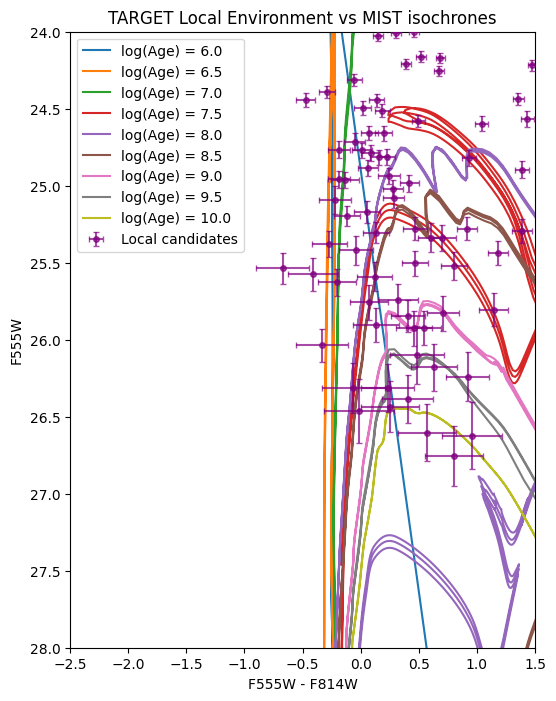

Best-fit log(age) = 7.05  (68% credible interval: 6.87 - 7.18)


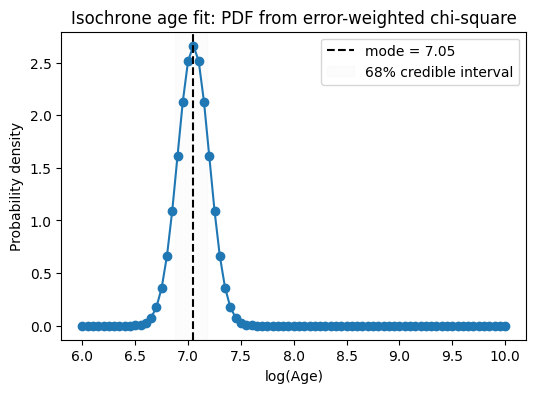

In [25]:
# age range isochrone!!
# scanning a range of ages instead of just eyeballing one. I tried first as a
# qualitative color-coded overlay, but then later I added an actual quantitative fit 

with h5py.File(filepath, 'r') as f:
    photo = f['photometry']
    err_555 = photo['Magnitude_uncertainty_ACS_F555W'][:][valid]
    err_814 = photo['Magnitude_uncertainty_ACS_F814W'][:][valid]
color_err = np.sqrt(err_555**2 + err_814**2)

# colors_list = ['blue', 'green', 'orange', 'red', 'brown']   # unused now, leftover from before I switched to the colormap

plt.figure(figsize=(6, 8))
plt.errorbar(f555 - f814, f555, xerr=color_err, yerr=err_555, fmt='o', color="purple", markersize=4, alpha=0.7, capsize=2, zorder=5, label="Local candidates")

ages_to_test = [6.0, 6.5, 7.0, 7.5, 8.0, 8.5, 9.0, 9.5, 10.0]
cmap = plt.colormaps['tab10']

for i, age in enumerate(ages_to_test):
    mask = np.isclose(iso_df['log10_isochrone_age_yr'], age, atol=0.01)
    if mask.sum() == 0:
        print(f"Warning: no isochrone points found for log(age)={age}")
        continue
    iso_555 = iso_df['ACS_WFC_F555W'][mask].values + distance_modulus + A_F555W
    iso_814 = iso_df['ACS_WFC_F814W'][mask].values + distance_modulus + A_F814W 
    plt.plot(iso_555 - iso_814, iso_555, color=cmap(i), label=f"log(Age) = {age}")

plt.gca().invert_yaxis()
plt.xlabel("F555W - F814W")
plt.ylabel("F555W")
plt.title("TARGET Local Environment vs MIST isochrones")
plt.legend()
plt.ylim(28, 24)
plt.xlim(-2.5, 1.5)
plt.show()

# error-weighted chi-square -> PDF! 
# Before i was using a error weight, so I wasn't dividing by the photometric
# uncertainties anywhere, so it was really just a sum of nearest-neighbor
# distances, not a real chi-square, and definitely not something I could
# turn into an error bar. 
# Weighting each star's contribution by its own
# color/mag uncertainty (dividing by sigma) makes this an actual
# chi-square statistic, which is what's needed to turn it into a
# probability in the next step.

ages_fine = np.arange(6.0, 10.01, 0.05)  # same finer grid as before, log(yr)
chi2_per_age = []  # (age, chi2) pairs, error-weighted this time

data_color = f555 - f814  # local candidate colors (same stars as the plot above)

for age in ages_fine:                                                    # loop over every trial age
    mask = np.isclose(iso_df['log10_isochrone_age_yr'], age, atol=0.01)  # this age's isochrone track
    if mask.sum() == 0:                                                  # skip ages missing from the grid
        continue
    iso_555 = iso_df['ACS_WFC_F555W'][mask].values + distance_modulus + A_F555W  # shift isochrone F555W to observed mags
    iso_814 = iso_df['ACS_WFC_F814W'][mask].values + distance_modulus + A_F814W  # shift isochrone F814W to observed mags
    iso_color = iso_555 - iso_814                                        # isochrone color at this age

    chi2 = 0.0                                                           # running chi2 total for this age
    for c, m, ce, me in zip(data_color, f555, color_err, err_555):       # loop over every star + its own errors
        d2 = ((c - iso_color) / ce)**2 + ((m - iso_555) / me)**2         # error-weighted squared distance, in units of each star's own sigma
        chi2 += d2.min()                                                 # nearest isochrone point wins, same nearest-neighbor idea as before
    chi2_per_age.append((age, chi2))                                     # store this age's chi2

ages_arr, chi2_arr = zip(*chi2_per_age)                                  # unpack into two tuples
ages_arr = np.array(ages_arr)                                            # ...then arrays, for the math below
chi2_arr = np.array(chi2_arr)

# turning chi2(age) into a PDF over age! 
# standard practice: the relative likelihood L(age) is proportional to
# exp(-chi2/2) (Wall & Jenkins 2012, "Practical Statistics for
# Astronomers", 2nd ed., Ch. 6 on chi-square and likelihood), and
# normalizing that over the age grid turns it into a proper probability
# density function instead of just a "best-fit + eyeballed" number
likelihood = np.exp(-0.5 * (chi2_arr - chi2_arr.min()))   # relative likelihood; subtracting chi2.min() just avoids exp() underflow
age_pdf = likelihood / np.trapezoid(likelihood, ages_arr)  # normalize so the PDF integrates to 1 over the age grid

#CHANGE!!!!
from scipy.ndimage import gaussian_filter1d
age_pdf = gaussian_filter1d(age_pdf, sigma=3)
age_pdf /= np.trapezoid(age_pdf, ages_arr)  # renormalize after smoothing

best_age = ages_arr[np.argmax(age_pdf)]                      # mode of the PDF = most probable age (same "best_age" definition as before)

# 68% credible interval! (equal-tailed, from the cumulative distribution)
cdf = np.cumsum(age_pdf) * np.gradient(ages_arr)             # numeric CDF via cumulative sum (gradient handles the age-grid step size)
cdf /= cdf[-1]                                               # renormalize so the CDF ends exactly at 1 (numeric cumsum can drift slightly)
age_lo = np.interp(0.16, cdf, ages_arr)                      # age below which 16% of the probability lies
age_hi = np.interp(0.84, cdf, ages_arr)                      # age below which 84% of the probability lies
                                                             # together these bracket 68%


print(f"Best-fit log(age) = {best_age:.2f}  (68% credible interval: {age_lo:.2f} - {age_hi:.2f})")

plt.figure(figsize=(6, 4))
plt.plot(ages_arr, age_pdf, marker='o')
plt.axvline(best_age, color='black', linestyle='--', label=f"mode = {best_age:.2f}")
plt.axvspan(age_lo, age_hi, color='gray', alpha=0.02, label="68% credible interval")
plt.xlabel("log(Age)")
plt.ylabel("Probability density")
plt.title("Isochrone age fit: PDF from error-weighted chi-square")
plt.legend()
plt.show()


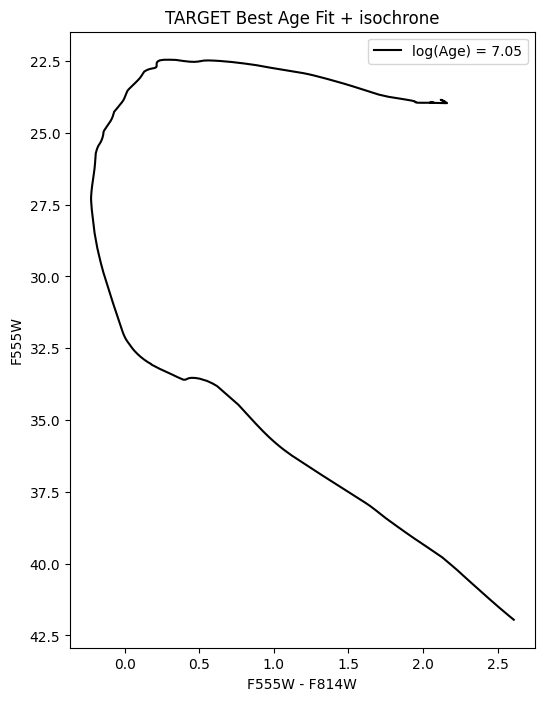

In [29]:
#isochrone!! Redoing this cell now with the best age (this time it's the
# PDF-fit age from the cell above)

target_log_age = best_age                                          # use the fitted age (PDF mode), not a guess

iso_mask = np.isclose(iso_df['log10_isochrone_age_yr'], target_log_age)  # age mask

iso_f555 = iso_df['ACS_WFC_F555W'][iso_mask].values               # isochrone F555W
iso_f814 = iso_df['ACS_WFC_F814W'][iso_mask].values                 # isochrone F814W

shifted_f555 = iso_f555 + distance_modulus + A_F555W                 # shift F555W
shifted_f814 = iso_f814 + distance_modulus + A_F814W               # shift F814W

# plot over existing plot (makes it not look squished)
plt.figure(figsize=(6, 8))                                          # set figure size

plt.plot(shifted_f555 - shifted_f814, shifted_f555,                 # plot isochrone
          color="black", label=f"log(Age) = {target_log_age:.2f}")

plt.gca().invert_yaxis()                                            # brighter stars up top
plt.xlabel("F555W - F814W")                                         # x-axis label
plt.ylabel("F555W")                                                 # y-axis label
plt.title("TARGET Best Age Fit + isochrone")                     # plot title
plt.legend()                                                         # show legend
plt.show()                                                           # display plot


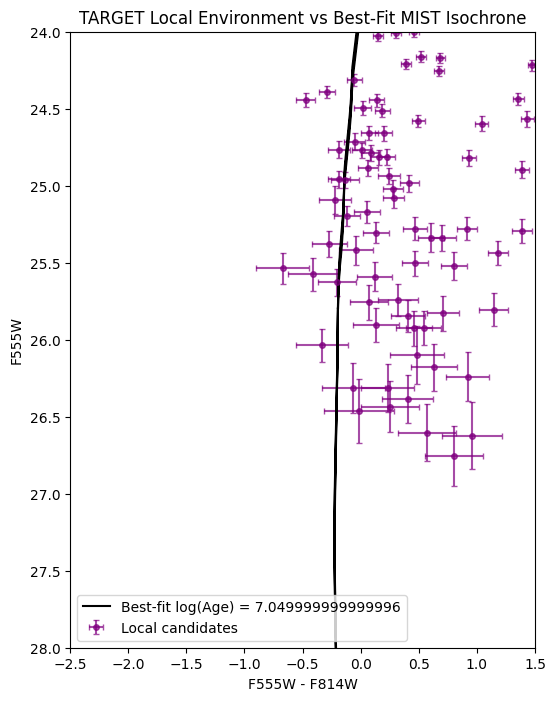

In [30]:
# isochrone at the fitted best age, overlaid on the local stars!!!
best_mask = np.isclose(iso_df['log10_isochrone_age_yr'], best_age, atol=0.01)

best_iso_f555 = iso_df['ACS_WFC_F555W'][best_mask].values
best_iso_f814 = iso_df['ACS_WFC_F814W'][best_mask].values

best_shifted_f555 = best_iso_f555 + distance_modulus + A_F555W
best_shifted_f814 = best_iso_f814 + distance_modulus + A_F814W 

plt.figure(figsize=(6, 8))
plt.errorbar(f555 - f814, f555, xerr=color_err, yerr=err_555, fmt='o',
             color="purple", markersize=4, alpha=0.7, capsize=2,
             label="Local candidates")
plt.plot(best_shifted_f555 - best_shifted_f814, best_shifted_f555,
          color="black", label=f"Best-fit log(Age) = {best_age}")

plt.gca().invert_yaxis()
plt.xlabel("F555W - F814W")
plt.ylabel("F555W")
plt.title("TARGET Local Environment vs Best-Fit MIST Isochrone")
plt.legend()
plt.ylim(28, 24)
plt.xlim(-2.5, 1.5)
plt.show()

### Track Interpolation + Mass estimation

In [33]:
# DATA INPUT (3 inputs needed)
# This will unzip the MIST track bundle (I'm using 5-35 Msun, step 0.5) into a folder we can scan

zip_path = "/Users/mari/Research/MIST_Evotracks/MIST8to25_eep_6a5fbb77cd2fe.zip"      # path to the zip file with all the track.eep files
extract_dir = "/Users/mari/Research/MIST_Evotracks/MIST8to25"                         # folder to unzip into

with zipfile.ZipFile(zip_path, 'r') as zf:                              # open the zip archive
    zf.extractall(extract_dir)                                          # extract every file inside it into extract_dir

extracted_tracks = glob.glob(os.path.join(extract_dir, "**", "*.track.eep"), recursive=True)  # find them even if nested in subfolders
print(f"Extracted {len(extracted_tracks)} track file(s) into {extract_dir}")  # confirm how many were found

track_dir = "/Users/mari/Research/MIST_Evotracks/MIST8to25"                                    # folder to scan for track files (add more masses here later)

Extracted 35 track file(s) into /Users/mari/Research/MIST_Evotracks/MIST8to25


In [34]:
# FUNCTION: get_progenitor_mass
# Pulled out of the "PROGENITOR MASS from evolutionary tracks" cell so it can
# be reused for the distance Monte Carlo (each trial age needs its own mass
# lookup, so this needs to be callable instead of just sitting inline in one cell)
# Takes a log(age) value and returns the interpolated progenitor mass, using
# the same mass <-> lifetime curve as before. Needs masses and lifetimes_yr
# to already exist (built once, from the track files, in the cell above)

def get_progenitor_mass(log_age_val):                                   # log_age_val lets the Monte Carlo pass in different trial ages
    if len(masses) < 2:                                                  # not enough tracks to interpolate
        return None                                                      # same "can't interpolate yet" case as the original cell

    age_yr = 10 ** log_age_val                                           # convert from log(yr) to plain years

    log_lifetimes = np.log10(lifetimes_yr)                               # work in log(lifetime), same as before
    order = np.argsort(log_lifetimes)                                    # np.interp needs x values increasing

    mass_val = np.interp(np.log10(age_yr), log_lifetimes[order], masses[order])  # interpolate mass at this age

    return mass_val                                                      # just the mass, that's all the Monte Carlo needs

Found 35 track file(s) in /Users/mari/Research/MIST_Evotracks/MIST8to25

0080000M.track.eep: mass = 8.00 Msun, lifetime = 4.087e+07 yr (log = 7.611)
0085000M.track.eep: mass = 8.50 Msun, lifetime = 3.621e+07 yr (log = 7.559)
0090000M.track.eep: mass = 9.00 Msun, lifetime = 3.243e+07 yr (log = 7.511)
0095000M.track.eep: mass = 9.50 Msun, lifetime = 2.954e+07 yr (log = 7.470)
0100000M.track.eep: mass = 10.00 Msun, lifetime = 2.665e+07 yr (log = 7.426)
0105000M.track.eep: mass = 10.50 Msun, lifetime = 2.461e+07 yr (log = 7.391)
0110000M.track.eep: mass = 11.00 Msun, lifetime = 2.257e+07 yr (log = 7.353)
0115000M.track.eep: mass = 11.50 Msun, lifetime = 2.102e+07 yr (log = 7.323)
0120000M.track.eep: mass = 12.00 Msun, lifetime = 1.948e+07 yr (log = 7.290)
0125000M.track.eep: mass = 12.50 Msun, lifetime = 1.832e+07 yr (log = 7.263)
0130000M.track.eep: mass = 13.00 Msun, lifetime = 1.717e+07 yr (log = 7.235)
0135000M.track.eep: mass = 13.50 Msun, lifetime = 1.631e+07 yr (log = 7.212)
0140000

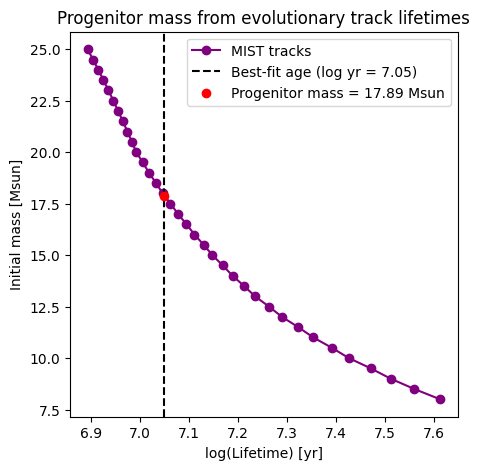

In [39]:
# PROGENITOR MASS from evolutionary tracks!!!
# idea: a star's total lifetime (time from birth to core collapse) depends on its mass
# More massive stars burn faster and die sooner. So if we know the age of
# the surrounding stellar population (best_age, from the isochrone fit above), we
# can ask "which initial mass has a lifetime equal to best_age?" and that's the
# progenitor mass!!! yippee!! 
# This scans the whole folder, so dropping more *.track.eep files in later
# will make the interpolation work automatically, no code changes needed.

def read_mist_track(filepath):                                         # parser function for a single *.track.eep file
    with open(filepath) as f:                                          # open the track file
        lines = f.readlines()                                          # read every line

    initial_mass = None                                                 # will hold this track's starting mass, in Msun
    colnames = None                                                     # will hold the column names
    data_rows = []                                                      # will hold the numeric data rows

    for i, line in enumerate(lines):                                   # loop through every line, keeping the index too
        if line.startswith('#'):                                       # comment/header line
            if 'initial_mass' in line and 'N_pts' in line:              # this is the header ROW LABEL line
                initial_mass = float(lines[i + 1].lstrip('#').split()[0])  # the mass value is on the NEXT comment line, first column
            if 'star_age' in line and 'star_mass' in line and colnames is None:  # this is the real column-names line
                colnames = line.lstrip('#').split()                     # grab the column names
            continue                                                    # skip to the next line, comments aren't data
        if line.strip():                                                # skip blank lines
            data_rows.append(line.split())                              # collect this row as data

    data = np.array(data_rows, dtype=float)                             # convert all collected rows to a numeric array
    df = pd.DataFrame(data, columns=colnames)                           # build a dataframe with proper column names
    return initial_mass, df                                             # return both the mass and the full track

track_files = sorted(glob.glob(os.path.join(track_dir, "**", "*.track.eep"), recursive=True))  # find every *.track.eep file in that folder

print(f"Found {len(track_files)} track file(s) in {track_dir}\n")       # quick count, so you know how many masses are loaded

masses = []                                                              # will hold each track's initial mass
lifetimes_yr = []                                                        # will hold each track's total lifetime, in years

for tf in track_files:                                                  # loop over every track file found
    mass, track_df = read_mist_track(tf)                                # parse this track file
    if mass is None:                                                    # header didn't have a parseable initial_mass
        print(f"Warning: couldn't find initial_mass in {tf}, skipping") # flag it here, at the source, instead of downstream
        continue                                                        # skip this file, move on to the next
    lifetime_yr = track_df['star_age'].max()                            # lifetime = age at the LAST row (end of the track, core collapse for massive stars)
    masses.append(mass)                                                 # store this track's mass
    lifetimes_yr.append(lifetime_yr)                                    # store this track's lifetime
    print(f"{os.path.basename(tf)}: mass = {mass:.2f} Msun, "           # print a summary line for this track
          f"lifetime = {lifetime_yr:.3e} yr (log = {np.log10(lifetime_yr):.3f})")  # lifetime in both linear and log form

masses = np.array(masses)                                               # convert mass list to an array
lifetimes_yr = np.array(lifetimes_yr)                                   # convert lifetime list to an array

sort_idx = np.argsort(masses)                                           # sort everything by mass, ascending
masses = masses[sort_idx]                                               # apply the sort to masses
lifetimes_yr = lifetimes_yr[sort_idx]                                   # apply the sort to lifetimes, keeping them paired

best_age_yr = 10 ** best_age                                            # best_age is log10(yr) from the isochrone fit, convert to plain years to compare

print(f"\nBest-fit population age: {best_age_yr:.3e} yr (log = {best_age:.3f})")  # print the target age we're solving against

if len(masses) < 2:                                                     # not enough tracks yet to interpolate a mass
    print(f"\nOnly {len(masses)} track(s) available, can't interpolate a progenitor mass yet.")  # explain the limitation
    print(f"{masses[0]:.2f} Msun track lifetime: {lifetimes_yr[0]:.3e} yr")  # show the one track's lifetime for comparison
    if lifetimes_yr[0] < best_age_yr:                                   # this star would already be dead by the fitted age
        print(f"-> the {masses[0]:.2f} Msun star would already be dead by the fitted age, "  # explain the direction
              f"so the true progenitor mass is LOWER than {masses[0]:.2f} Msun.")            # lower mass = longer lived
    else:                                                                # this star would still be alive at the fitted age
        print(f"-> the {masses[0]:.2f} Msun star would still be alive at the fitted age, "   # explain the direction
              f"so the true progenitor mass is HIGHER than {masses[0]:.2f} Msun.")           # higher mass = shorter lived
    progenitor_mass = None                                               # no interpolated value yet

    plt.figure(figsize=(5, 5))                                          # set up a small figure
    plt.scatter(np.log10(lifetimes_yr), masses, color="purple", s=60, zorder=5, label="Available track(s)")  # plot the one point we have
    plt.axvline(np.log10(best_age_yr), color="black", linestyle="--", label=f"Best-fit age (log yr = {best_age:.2f})")  # mark the target age
    plt.xlabel("log(Lifetime) [yr]")                                     # x-axis label
    plt.ylabel("Initial mass [Msun]")                                    # y-axis label
    plt.title("Progenitor mass vs lifetime (add more tracks to interpolate)")  # title, reminding this is partial
    plt.legend()                                                         # show the legend
    plt.show()                                                           # display the plot

else:                                                                    # two or more tracks, can interpolate a mass
    log_lifetimes = np.log10(lifetimes_yr)                               # work in log(lifetime), since mass-lifetime relations are steep/log-like
    order = np.argsort(log_lifetimes)                                    # np.interp needs x values increasing, so sort by log(lifetime)
    progenitor_mass = np.interp(np.log10(best_age_yr), log_lifetimes[order], masses[order])  # interpolate mass at the target log(age)
    print(f"\nInterpolated progenitor mass at best_age: {progenitor_mass:.2f} Msun")  # report the result

    plt.figure(figsize=(5, 5))                                          # set up a small figure
    plt.plot(log_lifetimes[order], masses[order], 'o-', color="purple", label="MIST tracks")  # plot mass vs log(lifetime) curve
    plt.axvline(np.log10(best_age_yr), color="black", linestyle="--", label=f"Best-fit age (log yr = {best_age:.2f})")  # mark the target age
    plt.scatter([np.log10(best_age_yr)], [progenitor_mass], color="red", zorder=5, label=f"Progenitor mass = {progenitor_mass:.2f} Msun")  # mark the answer
    plt.xlabel("log(Lifetime) [yr]")                                     # x-axis label
    plt.ylabel("Initial mass [Msun]")                                    # y-axis label
    plt.title("Progenitor mass from evolutionary track lifetimes")       # plot title
    plt.legend()                                                         # show the legend
    plt.show()                                                           # display the plot

Note: 66 age-grid point(s) fall outside the tracks' age range (6.89-7.61 log yr) and were excluded from the mass PDF.

Progenitor mass (mode of propagated PDF): 16.34 Msun
68% credible interval: 13.66 - 20.35 Msun


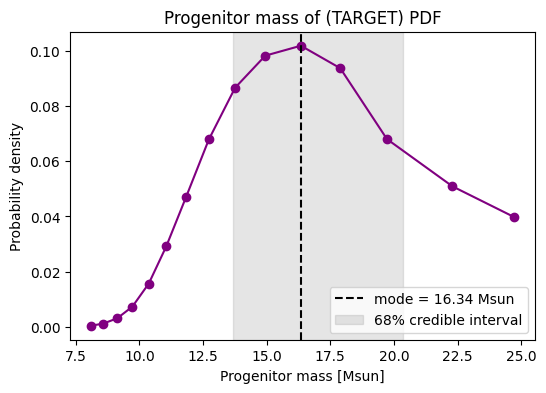

In [38]:
# PROGENITOR MASS PDF, propagated directly from the age PDF!!!!
# masses and ages are related by a monotonic 1-to-1 curve (mass <-> lifetime),
# so instead of just plugging best_age into that curve as a single point, we can
# push the entire age_pdf through it (standard change-of-variables for a monotonic
# transformation) to get a real mass PDF, with its own mode + credible interval

if len(masses) < 2:                                                     # need at least 2 tracks to interpolate mass from age
    print(f"Only {len(masses)} track(s) available, need 2+ to build a mass PDF. Add more mass tracks first.")  # explain why we can't proceed
else:                                                                    # enough tracks to build the mass <-> lifetime curve
    log_lifetimes_sorted = np.log10(lifetimes_yr)[np.argsort(np.log10(lifetimes_yr))]  # log(lifetime), sorted ascending (np.interp needs increasing x)
    masses_sorted_by_lifetime = masses[np.argsort(np.log10(lifetimes_yr))]  # masses, reordered to match the sorted lifetimes

    track_age_min = log_lifetimes_sorted.min()                          # youngest age covered by the tracks (highest mass's lifetime)
    track_age_max = log_lifetimes_sorted.max()                          # oldest age covered by the tracks (lowest mass's lifetime)

    in_range = (ages_arr >= track_age_min) & (ages_arr <= track_age_max)  # only keep ages actually spanned by the mass grid
    n_dropped = (~in_range).sum()                                       # how many age-grid points fall outside the track coverage
    if n_dropped > 0:                                                   # warn if some of the age PDF had to be dropped
        print(f"Note: {n_dropped} age-grid point(s) fall outside the tracks' age range "  # explain what's being excluded
              f"({track_age_min:.2f}-{track_age_max:.2f} log yr) and were excluded from the mass PDF.")  # show the actual covered range

    ages_in_range = ages_arr[in_range]                                  # age grid, restricted to track coverage
    age_pdf_in_range = age_pdf[in_range]                                # matching age PDF values

    mass_grid = np.interp(ages_in_range, log_lifetimes_sorted, masses_sorted_by_lifetime)  # map each in-range age to a mass, via the mass<->lifetime curve

    dmass_dage = np.gradient(mass_grid, ages_in_range)                  # local slope dMass/dlog(age), needed for the PDF change-of-variables
    nonzero = dmass_dage != 0                                           # guard against any remaining flat/zero-slope points
    mass_grid = mass_grid[nonzero]                                      # drop those points from the mass grid
    age_pdf_in_range = age_pdf_in_range[nonzero]                        # drop the matching age PDF values too
    dmass_dage = dmass_dage[nonzero]                                    # drop the matching slope values too

    mass_pdf_unsorted = age_pdf_in_range / np.abs(dmass_dage)           # change-of-variables: p_mass = p_age / |dMass/dAge|

    mass_order = np.argsort(mass_grid)                                  # mass_grid runs backwards (higher age = lower mass), so sort ascending for plotting/CDF
    mass_grid_sorted = mass_grid[mass_order]                            # masses, now in ascending order
    mass_pdf_sorted = mass_pdf_unsorted[mass_order]                     # matching PDF values, reordered the same way

    mass_pdf_sorted = mass_pdf_sorted / np.trapezoid(mass_pdf_sorted, mass_grid_sorted)  # renormalize so the mass PDF integrates to 1

    progenitor_mass_mode = mass_grid_sorted[np.argmax(mass_pdf_sorted)]  # mode of the mass PDF = most probable progenitor mass

    mass_cdf = np.cumsum(mass_pdf_sorted) * np.gradient(mass_grid_sorted)  # numeric CDF over the mass grid
    mass_cdf /= mass_cdf[-1]                                             # renormalize so the CDF ends exactly at 1
    mass_lo = np.interp(0.16, mass_cdf, mass_grid_sorted)                 # mass below which 16% of the probability lies
    mass_hi = np.interp(0.84, mass_cdf, mass_grid_sorted)                 # mass below which 84% of the probability lies, together, 68% CI

    print(f"\nProgenitor mass (mode of propagated PDF): {progenitor_mass_mode:.2f} Msun")  # headline result
    print(f"68% credible interval: {mass_lo:.2f} - {mass_hi:.2f} Msun")   # uncertainty range, inherited directly from the age fit

    plt.figure(figsize=(6, 4))                                          # set up the figure
    plt.plot(mass_grid_sorted, mass_pdf_sorted, marker='o', color="purple")  # plot the propagated mass PDF
    plt.axvline(progenitor_mass_mode, color="black", linestyle="--", label=f"mode = {progenitor_mass_mode:.2f} Msun")  # mark the mode
    plt.axvspan(mass_lo, mass_hi, color="gray", alpha=0.2, label="68% credible interval")  # shade the credible interval
    plt.xlabel("Progenitor mass [Msun]")                                 # x-axis label
    plt.ylabel("Probability density")                                    # y-axis label
    plt.title("Progenitor mass of (TARGET) PDF")                    # plot title, "(propagated from the age fit)"
    plt.legend()                                                         # show the legend
    plt.show()                                                           # display the plot

In [40]:
# CHECK: How much of the age PDF's probability mass falls inside
# the tracks' coverage, and on which side any excluded mass sits
# builds ONE continuous cumulative integral of age_pdf over the full ages_arr,
# then reads off values by interpolation at the track boundaries
# this avoids a bug where slicing the PDF into pieces before integrating separately drops
# the sliver of area that sits right at each boundary
# I ran into this bug while developing so am keeping here for safe measure!!

segment_areas = 0.5 * (age_pdf[1:] + age_pdf[:-1]) * np.diff(ages_arr)  # trapezoid area of each tiny interval between adjacent grid points
cum_mass = np.concatenate(([0.0], np.cumsum(segment_areas)))            # running cumulative total, starting at 0
cum_mass = cum_mass / cum_mass[-1]                                      # normalize so it reaches exactly 1.0 (age_pdf should already be ~normalized)

mass_below = np.interp(track_age_min, ages_arr, cum_mass)               # cumulative probability at/below the young-side boundary
mass_above = 1 - np.interp(track_age_max, ages_arr, cum_mass)           # cumulative probability at/above the old-side boundary
mass_covered = 1 - mass_below - mass_above                              # what's left in between

print(f"Track coverage: log(age) = {track_age_min:.2f} to {track_age_max:.2f}")  # remind what range the tracks cover
print(f"Covered:                          {100*mass_covered:.1f}%")      # inside track range
print(f"Excluded, YOUNG side (age < {track_age_min:.2f}): {100*mass_below:.1f}%")  # needs masses above your grid's max
print(f"Excluded, OLD side   (age > {track_age_max:.2f}): {100*mass_above:.1f}%")  # needs masses below your grid's min
print(f"Sum check (should be ~100%):       {100*(mass_covered+mass_below+mass_above):.1f}%")  # confirms the fix

if mass_covered < 0.95:                                                  # same 95% rule of thumb as before
    print("\n-> More than 5% of the age PDF's mass falls outside the tracks' age range.")
    print("   Extend the track grid to recover the missing coverage before trusting the mass CI.")
else:
    print("\n-> Coverage looks good, the excluded mass is a small tail.")

Track coverage: log(age) = 6.89 to 7.61
Covered:                          84.8%
Excluded, YOUNG side (age < 6.89): 15.2%
Excluded, OLD side   (age > 7.61): 0.0%
Sum check (should be ~100%):       100.0%

-> More than 5% of the age PDF's mass falls outside the tracks' age range.
   Extend the track grid to recover the missing coverage before trusting the mass CI.


Distance draws used: 500 (of 500 requested)

Age spread from distance alone:  0.045 dex (log yr)
Mass spread from distance alone: 1.428 Msun

Age uncertainty, photometric only:      +/- 0.151 dex
Age uncertainty, distance + photometric: +/- 0.157 dex
MC mean age: 7.06 (vs point-estimate best_age: 7.05)

Mass uncertainty, photometric only:      +/- 3.35 Msun
Mass uncertainty, distance + photometric: +/- 3.64 Msun


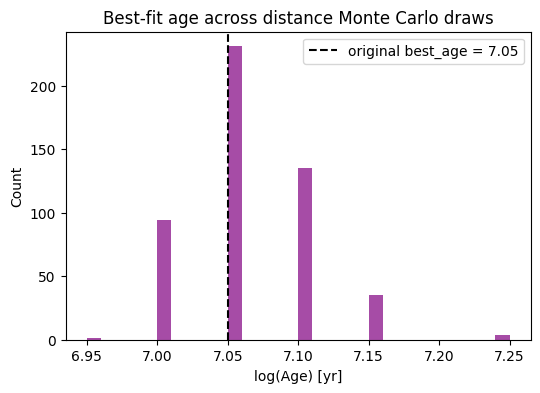

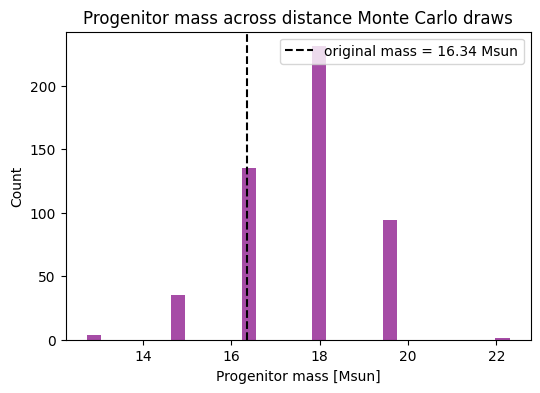

In [41]:
# DISTANCE MONTE CARLO: propagating distance_mpc_err into age and mass uncertainty
# distance_mpc_err was set way up in the target-inputs cell but was never
# actually used anywhere, so the age/mass credible intervals so far only
# reflect photometric scatter, not how uncertain the distance itself is
# This draws many trial distances from a Gaussian around distance_mpc, refits
# best_age and progenitor_mass for each one using the functions above, and
# looks at how much the answers move around just from distance alone

n_draws = 500                                                            # number of Monte Carlo distance draws

distance_draws = np.random.normal(distance_mpc, distance_mpc_err, n_draws)  # sample distances from a Gaussian
distance_draws = distance_draws[distance_draws > 0]                      # guard against a stray negative draw in the tail

best_ages_mc = []                                                        # will hold best_age from each draw
masses_mc = []                                                           # will hold progenitor_mass from each draw

for d in distance_draws:                                                 # loop over every trial distance
    d_pc = d * 1e6                                                       # Mpc -> pc
    dm = 5 * np.log10(d_pc) - 5                                          # distance modulus for this draw

    age_draw = fit_best_age(dm)                                          # refit best_age using this draw's distance modulus
    best_ages_mc.append(age_draw)                                        # store it

    mass_draw = get_progenitor_mass(age_draw)                            # get the progenitor mass for this draw's age
    if mass_draw is not None:                                            # only keep it if there were enough tracks to interpolate
        masses_mc.append(mass_draw)

best_ages_mc = np.array(best_ages_mc)                                    # convert to arrays for the stats below
masses_mc = np.array(masses_mc)

# spread from distance alone, holding the photometric fit method fixed
age_dist_err = best_ages_mc.std()                                        # standard deviation of best_age across all distance draws
mass_dist_err = masses_mc.std() if len(masses_mc) > 0 else None          # same for progenitor mass

print(f"Distance draws used: {len(distance_draws)} (of {n_draws} requested)")
print(f"\nAge spread from distance alone:  {age_dist_err:.3f} dex (log yr)")
if mass_dist_err is not None:
    print(f"Mass spread from distance alone: {mass_dist_err:.3f} Msun")

# combine with the existing photometric-scatter credible interval (age_lo/age_hi,
# mass_lo/mass_hi, from the earlier PDF fits) in quadrature, since these are two
# independent sources of uncertainty
age_photometric_err = (age_hi - age_lo) / 2                              # rough symmetric half-width from the earlier 68% CI
age_total_err = np.sqrt(age_photometric_err**2 + age_dist_err**2)        # combined uncertainty

print(f"\nAge uncertainty, photometric only:      +/- {age_photometric_err:.3f} dex")
print(f"Age uncertainty, distance + photometric: +/- {age_total_err:.3f} dex")
print(f"MC mean age: {best_ages_mc.mean():.2f} (vs point-estimate best_age: {best_age:.2f})")

if mass_dist_err is not None:
    mass_photometric_err = (mass_hi - mass_lo) / 2                       # rough symmetric half-width from the earlier mass PDF
    mass_total_err = np.sqrt(mass_photometric_err**2 + mass_dist_err**2) # combined uncertainty

    print(f"\nMass uncertainty, photometric only:      +/- {mass_photometric_err:.2f} Msun")
    print(f"Mass uncertainty, distance + photometric: +/- {mass_total_err:.2f} Msun")

# quick histogram of the age draws, to see the shape of the distance-driven spread
plt.figure(figsize=(6, 4))
plt.hist(best_ages_mc, bins=30, color="purple", alpha=0.7)
plt.axvline(best_age, color="black", linestyle="--", label=f"original best_age = {best_age:.2f}")
plt.xlabel("log(Age) [yr]")
plt.ylabel("Count")
plt.title("Best-fit age across distance Monte Carlo draws")
plt.legend()
plt.show()

# same histogram for mass, if it was possible to interpolate
if len(masses_mc) > 0:
    plt.figure(figsize=(6, 4))
    plt.hist(masses_mc, bins=30, color="purple", alpha=0.7)
    plt.axvline(progenitor_mass_mode, color="black", linestyle="--", label=f"original mass = {progenitor_mass_mode:.2f} Msun")
    plt.xlabel("Progenitor mass [Msun]")
    plt.ylabel("Count")
    plt.title("Progenitor mass across distance Monte Carlo draws")
    plt.legend()
    plt.show()

### DS9 + GAIA Check

In [42]:
#INPUT PATH TO SAVE FILE! 
reg_path = "/Users/mari/Research/summer26/supernovas/sn1964h/local_stars.reg"  # where to save the region file

In [47]:
# LIVE DS9 CONTROL via pyds9/XPA, 
# requires: pip install pyds9 
# This builds the star + SN + aperture regions directly 
# from the notebook's variables and sends them straight to an
# already-open DS9 session (so open ds9 first!!)
# If you change PHYSICAL_RADIUS_PC and rerun the pipeline, just rerun this 
# cell and the aperture circle sent to DS9 always matches what the code is
# actually using, it all goes automatically!!


# This has a try function built in, so that if the connection with pyds9 fails
# it will automatically tell you one of two possible errors (most likely ones)
# However if it doesn't work at all, there is another cell to create a .reg
# file that you can manually input into ds9

try:                                                                     # attempt the live connection
    import pyds9                                                        # the XPA-based DS9 control library

    ds9 = pyds9.DS9()                                                   # connect to the first open DS9 session on this machine

    ds9.set(f"file {reference_fits}")                                   # load the reference FITS image into DS9
    ds9.set("scale zscale")                                             # use zscale, DS9's standard auto-contrast for astro images
    ds9.set("zoom to fit")                                              # zoom so the whole image is visible

    region_lines = ["# Region file format: DS9", "image"]               # start building the region text, same header as the file version

    for x, y in zip(star_x, star_y):                                    # loop over every star that passed the cuts
        region_lines.append(f"circle({x:.2f},{y:.2f},5) # color=green width=1")  # green circle at each star's pixel position

    region_lines.append(f"circle({sn_x:.2f},{sn_y:.2f},8) # color=red width=2 text={{SN}}")  # red circle for the SN

    region_lines.append(                                                # yellow dashed circle for the CURRENT aperture, read live from the notebook's variables
        f"circle({sn_x:.2f},{sn_y:.2f},{max_radius_pixels:.2f}) "
        f"# color=yellow width=2 dash=1 text={{{PHYSICAL_RADIUS_PC:.0f} pc aperture}}"
    )

    region_text = "\n".join(region_lines)                                # join everything into one multi-line string

    ds9.set("regions", region_text)                                      # send the region text straight to DS9 over XPA, no file needed

    print(f"Sent {reference_fits} + {len(star_x)} star regions + SN + "  # confirm success
          f"{PHYSICAL_RADIUS_PC:.0f} pc aperture to DS9.")

except ImportError:                                                      # pyds9 isn't installed
    print("pyds9 not installed, run: pip install pyds9")               # tell them how to fix it
    print(f"In the meantime, use the region-file cell above and load {reg_path} manually.")  # fall back

except Exception as e:                                                   # connection failed for some other reason (DS9 not open, XPA not found, etc.)
    print(f"Couldn't connect to DS9: {e}")                               # show the actual error
    print("Make sure DS9 is already open, then re-run this cell.")       # most common fix
    print(f"In the meantime, use the region-file cell above and load {reg_path} manually.")  # fall back

Sent /Users/mari/Research/summer26/supernovas/sn1964h/acs.f814w.ut221110_0002.drc.fits + 109 star regions + SN + 300 pc aperture to DS9.


In [45]:
# DS9 REGION FILE 
# This marks every local-environment star, the SN itself, and the
# aperture boundary used for the radius cut
# This is so we can visually check both the star selection and whether the aperture is well-centered
# just open DS9, load reference_fits, then File -> Region -> Load Regions (or
# drag-and-drop) this .reg file on top

# This has overlap with the cell above. They do the same thing
# except this one will export a file, instead of automatically loading to ds9
# Can be useful if you want to send the region to someome
# but no need to run both

with open(reg_path, 'w') as f:                                          # open the file for writing (overwrites any previous version)
    f.write("# Region file format: DS9\n")                              # required DS9 region file header
    f.write("image\n")                                                  # coordinate system: image/pixel coords, matches star_x/star_y directly

    for x, y in zip(star_x, star_y):                                    # loop over every star that passed the cuts
        f.write(f"circle({x:.2f},{y:.2f},5) # color=green width=1\n")   # green circle, 5px radius, at each star's pixel position

    f.write(f"circle({sn_x:.2f},{sn_y:.2f},8) # color=red width=2 text={{SN}}\n")  # bigger red circle for the SN itself, labeled

    f.write(f"circle({sn_x:.2f},{sn_y:.2f},{max_radius_pixels:.2f}) "   # circle at the SN, radius = the actual aperture cut used in the notebook
            f"# color=yellow width=2 dash=1 text={{{PHYSICAL_RADIUS_PC:.0f} pc aperture}}\n")  # dashed yellow, labeled with the physical radius

# draw SEVERAL candidate apertures at once, so you can visually compare where
# each one lands relative to the star clump/association before picking one

candidate_radii_pc = [150, 300, 450, 600]                               # physical radii to compare, in pc 
colors = ["cyan", "yellow", "orange", "red"]                            # one color per radius, smallest to largest

with open(reg_path, 'a') as f:                                          # append to the same region file
    for r_pc, color in zip(candidate_radii_pc, colors):                 # loop over each candidate radius + its color
        r_arcsec = (r_pc / distance_pc) * 206265                        # convert this candidate's physical radius to angular size
        r_px = r_arcsec / PLATE_SCALE                                   # convert angular size to pixels, same formula as the DERIVED cell
        f.write(f"circle({sn_x:.2f},{sn_y:.2f},{r_px:.2f}) "            # circle at the SN, at this candidate radius
                f"# color={color} width=1 dash=1 text={{{r_pc} pc}}\n") # colored + labeled by physical radius

print(f"Added {len(candidate_radii_pc)} candidate aperture circles to {reg_path}")  # confirm

print(f"Wrote {len(star_x)} star regions + SN + aperture boundary to {reg_path}")  # confirm it worked and how many regions were written
print(f"\nIn DS9: File -> Open... -> {reference_fits}")                 # instructions, step 1
print(f"Then:   File -> Region -> Load Regions... -> {reg_path}")       # instructions, step 2

Added 4 candidate aperture circles to /Users/mari/Research/summer26/supernovas/sn1964h/local_stars.reg
Wrote 109 star regions + SN + aperture boundary to /Users/mari/Research/summer26/supernovas/sn1964h/local_stars.reg

In DS9: File -> Open... -> /Users/mari/Research/summer26/supernovas/sn1964h/acs.f814w.ut221110_0002.drc.fits
Then:   File -> Region -> Load Regions... -> /Users/mari/Research/summer26/supernovas/sn1964h/local_stars.reg


In [46]:
# CROSS-MATCH against Gaia to flag foreground Milky Way star contamination!!!!
# The host galaxy for these targets are likley super far away
# and will have a tinyyyy parallax (e.g sn1964h ~0.00008 mas), which is
# WAY below Gaia's precision (~0.02-0.04 mas typical). 
# So any star with a statistically significant Gaia parallax detection CANNOT 
# be a member of the host galaxy  it has to be a foreground Milky Way star 
# sitting in the same line of sight

sn_coord_query = SkyCoord(ra=sn_ra * u.deg, dec=sn_dec * u.deg, frame='icrs')  # SN position, as the center of the Gaia search
search_radius = (max_radius_arcsec + 5) * u.arcsec                      # aperture radius + a little padding, so nothing right at the edge gets missed

job = Gaia.cone_search_async(sn_coord_query, radius=search_radius)      # query Gaia (DR3 by default) for everything in that patch of sky
gaia_results = job.get_results()                                        # pull down the actual results table

print(f"Found {len(gaia_results)} Gaia source(s) within {search_radius:.1f} of the SN")  # sanity check on how many Gaia sources are nearby

star_coords = SkyCoord(ra=star_ra * u.deg, dec=star_dec * u.deg, frame='icrs')  # your local-environment stars, as SkyCoord objects
gaia_coords = SkyCoord(ra=gaia_results['ra'], dec=gaia_results['dec'], frame='icrs')  # the Gaia sources, as SkyCoord objects

match_radius = 0.3 * u.arcsec                                           # how close counts as "the same star"

if len(gaia_coords) > 0:                                                # only attempt matching if Gaia actually returned sources
    idx, sep2d, _ = star_coords.match_to_catalog_sky(gaia_coords)       # for each of your stars, find its nearest Gaia source + the separation
    is_matched = sep2d < match_radius                                  # True where that nearest Gaia source is close enough to count as a real match
else:                                                                    # no Gaia sources at all in this field
    is_matched = np.zeros(len(star_x), dtype=bool)                      # nothing can be matched

is_foreground = np.zeros(len(star_x), dtype=bool)                       # will hold True for stars flagged as likely foreground contamination

for i in range(len(star_x)):                                            # loop over every local-environment star
    if not is_matched[i]:                                               # no Gaia counterpart, can't say anything about it, leave unflagged
        continue                                                        # move to the next star
    gaia_row = gaia_results[idx[i]]                                     # the matched Gaia row for this star
    parallax = gaia_row['parallax']                                     # Gaia parallax, in mas (can be negative/noisy for faint or distant sources)
    parallax_err = gaia_row['parallax_error']                           # Gaia's quoted uncertainty on that parallax
    if parallax_err is not None and parallax_err > 0:                   # guard against missing/zero uncertainty values
        significance = parallax / parallax_err                         # how many sigma away from zero the parallax measurement is
        if significance > 3:                                            # a >3 sigma nonzero parallax can't be at 12.82 Mpc
            is_foreground[i] = True                                     # flag this star as likely foreground contamination

n_flagged = is_foreground.sum()                                         # total count of flagged stars
print(f"\n{is_matched.sum()} of {len(star_x)} local stars matched to a Gaia source")  # how many stars had any Gaia counterpart at all
print(f"{n_flagged} star(s) flagged as likely FOREGROUND (significant Gaia parallax, can't be at {distance_mpc} Mpc)")  # the actual headline number

if n_flagged > 0:                                                       # only print details if something was actually flagged
    print(f"\n{'#':<4} {'x (px)':<10} {'y (px)':<10} {'parallax (mas)':<16} {'sigma'}")  # table header
    for i in np.where(is_foreground)[0]:                                # loop over just the flagged stars
        gaia_row = gaia_results[idx[i]]                                 # matched Gaia row again, for printing
        sig = gaia_row['parallax'] / gaia_row['parallax_error']         # recompute significance for display
        print(f"{i:<4} {star_x[i]:<10.2f} {star_y[i]:<10.2f} {gaia_row['parallax']:<16.4f} {sig:.1f}")  # print one row per flagged star

INFO: Query finished. [astroquery.utils.tap.core]
Found 1 Gaia source(s) within 10.2 arcsec of the SN

0 of 109 local stars matched to a Gaia source
0 star(s) flagged as likely FOREGROUND (significant Gaia parallax, can't be at 11.82 Mpc)


### Diagnostics :)

This is meant to help with troubleshooting issues I had while trying to craft this code 

- Diagnostic 1: is a few stars with tiny error bars dominating the age fit?
- Diagnostic 2: star count funnel (no cuts -> radius cut -> radius + quality cuts)
- Diagnostic 3: which quality cut is removing the most stars?
- Diagnostic 4: is the peak at best_age genuinely better, or a coincidental spike?
- Diagnostic 5: star count with updated quality cuts (SNR >= 3, sharpness +/- 0.5)
- Sanity Check 1: quick peek at an evolutionary track file's header

In [35]:
# DIAGNOSTIC 1: is a few stars with tiny error bars dominating the age fit?
# Not part of the fit itself, I just added this to check whether the 1/error^2
# weighting above is spread out over the sample, or getting hijacked by
# one or two stars with implausibly small DOLPHOT errors, before I trust
# how much best_age moved from the old unweighted version

# This was happening pretty heavily before i updated the quality cuts, so that might be something to consider.

# sanity check on the error values themselves
# if any of these are suspiciously close to zero, that's a red flag on its own
print("color_err: min = {:.4f}, median = {:.4f}, max = {:.4f}".format(
    color_err.min(), np.median(color_err), color_err.max()))
print("err_555:   min = {:.4f}, median = {:.4f}, max = {:.4f}".format(
    err_555.min(), np.median(err_555), err_555.max()))

# this is to recompute each star's individual chi2 contribution at best_age (same
# weighting as the fit above, just kept per-star instead of summed) so I
# can see whether it's spread across the sample or dominated by a handful
best_mask = np.isclose(iso_df['log10_isochrone_age_yr'], best_age, atol=0.01)
best_iso_555 = iso_df['ACS_WFC_F555W'][best_mask].values + distance_modulus + A_F555W
best_iso_814 = iso_df['ACS_WFC_F814W'][best_mask].values + distance_modulus + A_F814W
best_iso_color = best_iso_555 - best_iso_814

star_chi2 = np.zeros(len(data_color))                                    # one chi2 value per star
for i, (c, m, ce, me) in enumerate(zip(data_color, f555, color_err, err_555)):
    d2 = ((c - best_iso_color) / ce)**2 + ((m - best_iso_555) / me)**2   # same weighting as the fit above
    star_chi2[i] = d2.min()

total_chi2 = star_chi2.sum()
frac_of_total = star_chi2 / total_chi2                                    # each star's share of the total chi2

order = np.argsort(star_chi2)[::-1]                                       # biggest contributors first
print(f"\ntotal chi2 at best_age = {best_age:.2f}: {total_chi2:.2f}, from {len(data_color)} stars")
print("top 10 individual contributors (star index, chi2, % of total, color_err, mag_err):")
for i in order[:10]:
    print(f"  idx {i}: chi2 = {star_chi2[i]:.2f}  ({100*frac_of_total[i]:.1f}% of total)  "
          f"color_err = {color_err[i]:.4f}  mag_err = {err_555[i]:.4f}")


color_err: min = 0.0135, median = 0.0922, max = 0.3013
err_555:   min = 0.0100, median = 0.0680, max = 0.2160

total chi2 at best_age = 7.05: 15206.68, from 109 stars
top 10 individual contributors (star index, chi2, % of total, color_err, mag_err):
  idx 21: chi2 = 1465.09  (9.6% of total)  color_err = 0.0520  mag_err = 0.0480
  idx 40: chi2 = 716.56  (4.7% of total)  color_err = 0.0762  mag_err = 0.0720
  idx 0: chi2 = 704.72  (4.6% of total)  color_err = 0.0135  mag_err = 0.0100
  idx 7: chi2 = 703.77  (4.6% of total)  color_err = 0.0326  mag_err = 0.0250
  idx 24: chi2 = 695.70  (4.6% of total)  color_err = 0.0783  mag_err = 0.0760
  idx 14: chi2 = 680.60  (4.5% of total)  color_err = 0.0311  mag_err = 0.0230
  idx 12: chi2 = 548.30  (3.6% of total)  color_err = 0.0559  mag_err = 0.0510
  idx 25: chi2 = 539.12  (3.5% of total)  color_err = 0.0419  mag_err = 0.0320
  idx 22: chi2 = 497.21  (3.3% of total)  color_err = 0.0566  mag_err = 0.0480
  idx 4: chi2 = 477.35  (3.1% of total) 

In [393]:
# DIAGNOSTIC 2: star count funnel (no cuts -> radius cut -> radius + quality cuts)
# Re-reads from filepath independently

with h5py.File(filepath, 'r') as f:
    photo = f['photometry']
    f555_raw = photo['Instrumental_VEGAMAG_magnitude_ACS_F555W'][:]
    f814_raw = photo['Instrumental_VEGAMAG_magnitude_ACS_F814W'][:]
    x_coords = photo['Object_X_position_on_reference_image_or_first_image_if_no_refer'][:]
    y_coords = photo['Object_Y_position_on_reference_image_or_first_image_if_no_refer'][:]
    obj_type = photo['Object_type_1_bright_star_2_faint_3_elongated_4_hot_pixel_5_ext'][:]
    flag_555 = photo['Photometry_quality_flag_ACS_F555W'][:]
    flag_814 = photo['Photometry_quality_flag_ACS_F814W'][:]
    snr_555 = photo['Signal_to_noise_ACS_F555W'][:]
    sharp_555 = photo['Sharpness_ACS_F555W'][:]
    crowd_555 = photo['Crowding_ACS_F555W'][:]
    snr_814 = photo['Signal_to_noise_ACS_F814W'][:]
    sharp_814 = photo['Sharpness_ACS_F814W'][:]
    crowd_814 = photo['Crowding_ACS_F814W'][:]
    scraped = f['scraped_photometry'].attrs
    cx = float(scraped['x'])
    cy = float(scraped['y'])

# Stage 0: no cuts at all besides the dolphot 99.99 flag
no_cuts = (f555_raw < 50) & (f814_raw < 50)
print(f"Stage 0 - No cuts (whole chip):        {no_cuts.sum()} stars")

# Stage 1: + radius cut only
dist_px = np.sqrt((x_coords - cx)**2 + (y_coords - cy)**2)
radius_only = no_cuts & (dist_px < max_radius_pixels)
print(f"Stage 1 - + radius cut ({max_radius_pixels:.0f}px):       {radius_only.sum()} stars")

# Stage 2: + quality cuts (same thresholds as your cell 12)
quality_and_radius = (
    radius_only &
    (obj_type == 1) &
    (flag_555 <= 2) & (flag_814 <= 2) &
    (snr_555 >= 5.0) & (snr_814 >= 5.0) &
    (crowd_555 < 0.5) & (crowd_814 < 0.5) &
    (sharp_555 > -0.3) & (sharp_555 < 0.3) &
    (sharp_814 > -0.3) & (sharp_814 < 0.3)
)
print(f"Stage 2 - + quality cuts:              {quality_and_radius.sum()} stars")

print(f"\nRadius cut removed:  {no_cuts.sum() - radius_only.sum()} stars")
print(f"Quality cuts removed: {radius_only.sum() - quality_and_radius.sum()} stars")

Stage 0 - No cuts (whole chip):        38262 stars
Stage 1 - + radius cut (105px):       532 stars
Stage 2 - + quality cuts:              121 stars

Radius cut removed:  37730 stars
Quality cuts removed: 411 stars


In [285]:
# DIAGNOSTIC 3: which individual quality cut is removing the most stars?
# Applied one at a time, starting from the 153 stars that pass the radius cut

with h5py.File(filepath, 'r') as f:
    photo = f['photometry']
    f555_raw = photo['Instrumental_VEGAMAG_magnitude_ACS_F555W'][:]
    f814_raw = photo['Instrumental_VEGAMAG_magnitude_ACS_F814W'][:]
    x_coords = photo['Object_X_position_on_reference_image_or_first_image_if_no_refer'][:]
    y_coords = photo['Object_Y_position_on_reference_image_or_first_image_if_no_refer'][:]
    obj_type = photo['Object_type_1_bright_star_2_faint_3_elongated_4_hot_pixel_5_ext'][:]
    flag_555 = photo['Photometry_quality_flag_ACS_F555W'][:]
    flag_814 = photo['Photometry_quality_flag_ACS_F814W'][:]
    snr_555 = photo['Signal_to_noise_ACS_F555W'][:]
    sharp_555 = photo['Sharpness_ACS_F555W'][:]
    crowd_555 = photo['Crowding_ACS_F555W'][:]
    snr_814 = photo['Signal_to_noise_ACS_F814W'][:]
    sharp_814 = photo['Sharpness_ACS_F814W'][:]
    crowd_814 = photo['Crowding_ACS_F814W'][:]
    scraped = f['scraped_photometry'].attrs
    cx = float(scraped['x'])
    cy = float(scraped['y'])

dist_px = np.sqrt((x_coords - cx)**2 + (y_coords - cy)**2)
base = (f555_raw < 50) & (f814_raw < 50) & (dist_px < max_radius_pixels)
print(f"Starting sample (radius cut only): {base.sum()} stars\n")

cuts = {
    "obj_type == 1":            (obj_type == 1),
    "flag_555 <= 2":             (flag_555 <= 2),
    "flag_814 <= 2":             (flag_814 <= 2),
    "snr_555 >= 5.0":            (snr_555 >= 5.0),
    "snr_814 >= 5.0":            (snr_814 >= 5.0),
    "crowd_555 < 0.5":           (crowd_555 < 0.5),
    "crowd_814 < 0.5":           (crowd_814 < 0.5),
    "sharp_555 in [-0.3, 0.3]":  (sharp_555 > -0.3) & (sharp_555 < 0.3),
    "sharp_814 in [-0.3, 0.3]":  (sharp_814 > -0.3) & (sharp_814 < 0.3),
}

print(f"{'Cut':<28} {'Pass alone (of base)':<22} {'Removed by this cut'}")
for name, mask in cuts.items():
    combined = base & mask
    passed = combined.sum()
    removed = base.sum() - passed
    print(f"{name:<28} {passed:<22} {removed}")

Starting sample (radius cut only): 455 stars

Cut                          Pass alone (of base)   Removed by this cut
obj_type == 1                455                    0
flag_555 <= 2                455                    0
flag_814 <= 2                455                    0
snr_555 >= 5.0               240                    215
snr_814 >= 5.0               304                    151
crowd_555 < 0.5              390                    65
crowd_814 < 0.5              373                    82
sharp_555 in [-0.3, 0.3]     235                    220
sharp_814 in [-0.3, 0.3]     308                    147


In [72]:
# DIAGNOSTIC 4: is the peak at best_age genuinely better, or a coincidental spike?
# prints chi2 for the ages right around the peak, plus the % difference
# from best_age's chi2, so you can see if it's a real signal or a fluke

peak_idx = np.argmin(chi2_arr)
window = 5

lo = max(0, peak_idx - window)
hi = min(len(ages_arr), peak_idx + window + 1)

print(f"Peak at log(age) = {ages_arr[peak_idx]:.2f}, chi2 = {chi2_arr[peak_idx]:.2f}")
print(f"Total ages in chi2_arr: {len(chi2_arr)}\n")
print(f"{'log(Age)':<10} {'chi2':<10} {'% above min chi2'}")
for i in range(lo, hi):
    pct_above = 100 * (chi2_arr[i] - chi2_arr[peak_idx]) / chi2_arr[peak_idx]
    marker = "  <-- peak" if i == peak_idx else ""
    print(f"{ages_arr[i]:<10.2f} {chi2_arr[i]:<10.2f} {pct_above:>6.1f}%{marker}")

Peak at log(age) = 7.05, chi2 = 20148.62
Total ages in chi2_arr: 81

log(Age)   chi2       % above min chi2
6.80       42739.99    112.1%
6.85       41211.83    104.5%
6.90       36098.83     79.2%
6.95       28947.03     43.7%
7.00       22893.96     13.6%
7.05       20148.62      0.0%  <-- peak
7.10       20628.37      2.4%
7.15       25556.28     26.8%
7.20       36260.70     80.0%
7.25       45967.74    128.1%
7.30       64759.69    221.4%


In [286]:
# DIAGNOSTIC 5: star count with updated quality cuts (SNR >= 3, sharpness +/- 0.5)

with h5py.File(filepath, 'r') as f:
    photo = f['photometry']
    f555_raw = photo['Instrumental_VEGAMAG_magnitude_ACS_F555W'][:]
    f814_raw = photo['Instrumental_VEGAMAG_magnitude_ACS_F814W'][:]
    x_coords = photo['Object_X_position_on_reference_image_or_first_image_if_no_refer'][:]
    y_coords = photo['Object_Y_position_on_reference_image_or_first_image_if_no_refer'][:]
    obj_type = photo['Object_type_1_bright_star_2_faint_3_elongated_4_hot_pixel_5_ext'][:]
    flag_555 = photo['Photometry_quality_flag_ACS_F555W'][:]
    flag_814 = photo['Photometry_quality_flag_ACS_F814W'][:]
    snr_555 = photo['Signal_to_noise_ACS_F555W'][:]
    sharp_555 = photo['Sharpness_ACS_F555W'][:]
    crowd_555 = photo['Crowding_ACS_F555W'][:]
    snr_814 = photo['Signal_to_noise_ACS_F814W'][:]
    sharp_814 = photo['Sharpness_ACS_F814W'][:]
    crowd_814 = photo['Crowding_ACS_F814W'][:]
    scraped = f['scraped_photometry'].attrs
    cx = float(scraped['x'])
    cy = float(scraped['y'])

dist_px = np.sqrt((x_coords - cx)**2 + (y_coords - cy)**2)
base = (f555_raw < 50) & (f814_raw < 50) & (dist_px < max_radius_pixels)

updated_valid = (
    base &
    (obj_type == 1) &
    (flag_555 <= 2) & (flag_814 <= 2) &
    (snr_555 >= 3.0) & (snr_814 >= 3.0) &
    (crowd_555 < 0.5) & (crowd_814 < 0.5) &
    (sharp_555 > -0.4) & (sharp_555 < 0.4) &
    (sharp_814 > -0.4) & (sharp_814 < 0.4)
)

print(f"Radius cut only:              {base.sum()} stars")
print(f"+ updated quality cuts:       {updated_valid.sum()} stars")

Radius cut only:              455 stars
+ updated quality cuts:       166 stars


In [269]:
# SANITY CHECK 1
# quick peek at the evolutionary track file's header, so we know its real column layout
# This is more of a sanity check if you need to check a specific track for any reason
track_path = "/Users/mari/Research/0080000M.track.eep"

with open(track_path) as f:
    lines = f.readlines()

header_lines = [l for l in lines if l.startswith('#')]
print(''.join(header_lines[:20]))   # first 20 comment lines, should include the column names row

# MIST version number  = 2.5     
# MESA revision number =    11701
# --------------------------------------------------------------------------------------
#  Yinit        Zinit   [Fe/H]   [a/Fe]  v/vcrit                                        
# 0.2703  1.63577E-02     0.00     0.00     0.40
# --------------------------------------------------------------------------------------
#     initial_mass   N_pts   N_EEP   N_col   phase        type
# 8.0000000000E+00     808       8     168     YES    low-mass
# EEPs:        1     202     353     454     605     631     707     808
# --------------------------------------------------------------------------------------
#                               1                               2                               3                               4                               5                               6                               7                               8                               9                              10       

### Old Cells